<p style="text-align: center; font-size: 28px; font-weight: bold;">
Exploring Gendered Framing in Wikipedia Science Biographies
</p>

<p style="text-align: center; font-size: 18px; font-weight: bold;">
DTU 2026 - Computational Social Science, Final Project
</p>

This explainer notebook will contain the technical side of the project: data collection, cleaning, text analysis, network construction, statistical testing, and limitations as well as our research motivation and notes on the design choices.

The public-facing website should tell the story in a simpler way. This notebook instead explains the methodological choices behind that story: what data was collected, how the text was processed, how the word networks were built, and how the evidence was evaluated.

For further inquiries, please write us at:
s223719@dtu.dk and s213304@dtu.dk

# 1. Motivation: Research Question

Wikipedia is one of the most widely used sources of knowledge in the public domain. For many readers, it is the first place they encounter information about scientists, discoveries, and scientific history. Because of this, Wikipedia biographies not only provides us with facts, but they also shape how scientists are presented.

Although Wikipedia is often perceived as neutral, in the end, biographies are written and edited by people. This means that the language used in an article may reflect broader social patterns, editorial habits, historical inequalities, or differences in what information is available about different groups of people. In the case of scientists, this is especially interesting because scientific achievement is often imagined as objective and merit-based, while the way scientists are described may still vary depending on gender. It may also be the case that the nature of male and females in the field simply have fundamentally different qualities, that are reflected in the presentation of the biographies. This project aims to provide discussions with data and tools for elucidating the nature of biographical framings. 

More specifically, this project investigates whether English Wikipedia biographies of male and female scientists in STEM differ in their textual and semantic framing. We are not trying to prove that Wikipedia is intentionally biased, or that any observed difference is caused by gender alone as there are many confounders. Instead, we treat the biographies as a large collection of socially produced texts and explore whether systematic patterns appear in how male and female scientists are described.

Our guiding research question is:

**Do English Wikipedia biographies describe male and female scientists in STEM differently in terms of thematic focus and semantic structure?**

More specifically, we examine whether biographies differ in:

- article length and amount of coverage,
- important words and recurring themes,
- gender-associated words and phrases,
- the balance between science-related and family-related language,
- and the way concepts are connected in word co-occurrence networks.
- we also validate our findings with a statistical test against the sample.

Because Wikipedia coverage is uneven across scientific fields, we compare scientists within broad STEM fields rather than treating all biographies as one homogeneous group. This makes the comparison fairer, since differences between, for example, physicists and biologists should not be mistaken for gender differences.

## End-User Goal

The intended end user is a non-technical reader who is interested in how public knowledge about scientists is constructed. The goal is to make gendered patterns in Wikipedia biographies easier to see, without requiring the reader to understand the full technical details of text analysis or network science.

The project is designed to guide the reader from simple observations to more complex analysis. It begins with basic descriptive statistics, such as article length and sample composition, before moving into word-based comparisons, thematic categories, and semantic word co-occurrence networks. This allows the reader to first understand the dataset and then gradually see how computational methods can reveal patterns in language.

A central goal of the project is also to communicate uncertainty. The analysis is exploratory in nature, and the results should not be read as proof of discrimination or as causal evidence of gender bias. We are not claiming bias, but merely implore users to analyze underlying social patterns, regardles of its causal nature. Instead, the project aims to show how computational social science tools can be used to investigate possible differences in representation, while also making the limitations of those tools visible.

**The data pipeline is structured as follows:**
- **Data**
  - API, Preprocessing and Stats
- **Semantic analysis**
  - TF-IDF, Log-odds, Bigrams, Themes
- **Network analysis**
  - Word co-occurrence, Network Measures
- **Statistical testing**
  - Permutation tests, Bonferroni correction
- **Discussion and limitations**

# Dataset: Collection, Stats and Processing

## Collecting Scientists from Wikidata and Wikipedia

This section collects biographies using two APIs:

- **Wikidata SPARQL API**: used to find people with English Wikipedia pages, a gender label, and an occupation related to one of five scientific fields.
- **Wikipedia API**: used to download the plain-text biography for each selected person.

Five fields are chosen and used as a focused STEM case selection rather than a complete map of all STEM disciplines. We include computer science, physics, chemistry, mathematics, and biology because they are large, recognizable scientific fields with clear Wikidata occupation labels and enough English Wikipedia biographies for both women and men after filtering.

Engineering, medicine, geology, astronomy, and other STEM-adjacent fields are disregarded, partly because occupational labels in Wikidata overlap and can make field boundaries less clean. Restricting the analysis to five broad fields reduces ambiguity, but at the cost of representativeness.

This choice makes the project more reproducible and keeps the matched comparison feasible. However, it also limits the scope of the conclusions. The results should be interpreted as patterns within these five selected STEM-related fields, not as claims about all STEM biographies. You are welcome to make additions to the notebook for further research.

For each field, the notebook queries biographies for women and men separately, then downloads the corresponding article text. We also compute simple text statistics such as article length and word count.


**Data Summary**
| Item | Description |
|---|---|
| **Source** | Wikidata + English Wikipedia |
| **Unit of analysis** | Scientist biography |
| **Scientific fields** | Computer science, physics, chemistry, mathematics, biology |
| **Gender groups** | Women and men |
| **Initial sample** | 458 people before filtering |
| **Filtered sample** | 269 biographies after applying the >500 word filter |
| **Balanced sample** | 180 biographies: 90 women and 90 men |
| **Final design** | 18 women and 18 men from each scientific field |

Important limitation: the initial Wikidata query is not a random sample of all scientists on Wikipedia. The final sample is balanced only after filtering, by randomly sampling the same number of biographies from each field-gender group.

In [41]:
import requests
import pandas as pd
import time

In [ ]:
WIKIPEDIA_URL = "https://en.wikipedia.org/w/api.php"
WIKIDATA_SPARQL_URL = "https://query.wikidata.org/sparql"

HEADERS = {
    "User-Agent": "DTU-Student-Project/1.0 (andrew.b.osias@gmail.com)"
}


FEMALE = "Q6581072"
MALE = "Q6581097"

FIELDS = {
    "computer_scientist": "Q82594",
    "physicist": "Q169470",
    "chemist": "Q593644",
    "mathematician": "Q170790",
    "biologist": "Q864503",
}


def query_wikidata_by_field(gender_qid, occupation_qid, field_name, limit=10, retries=3):
    query = f"""
    SELECT ?person ?personLabel ?article WHERE {{
      ?person wdt:P31 wd:Q5;
              wdt:P21 wd:{gender_qid};
              wdt:P106 wd:{occupation_qid}.

      ?article schema:about ?person;
               schema:isPartOf <https://en.wikipedia.org/>.

      SERVICE wikibase:label {{
        bd:serviceParam wikibase:language "en".
      }}
    }}
    LIMIT {limit}
    """

    params = {
        "query": query,
        "format": "json"
    }

    for attempt in range(retries):
        try:
            response = requests.get(
                WIKIDATA_SPARQL_URL,
                params=params,
                headers=HEADERS,
                timeout=90
            )

            print(f"{field_name} | {gender_qid} | attempt {attempt + 1} | status:", response.status_code)

            if response.status_code != 200:
                print(response.text[:500])
                time.sleep(5)
                continue

            data = response.json()

            rows = []

            for item in data["results"]["bindings"]:
                article_url = item["article"]["value"]
                title = article_url.split("/wiki/")[-1].replace("_", " ")

                rows.append({
                    "person": item["person"]["value"],
                    "name": item["personLabel"]["value"],
                    "article_url": article_url,
                    "title": title,
                    "field": field_name
                })

            return pd.DataFrame(rows)

        except requests.exceptions.ReadTimeout:
            print(f"Timeout for {field_name}, gender {gender_qid}. Retrying...")
            time.sleep(10)

        except requests.exceptions.RequestException as e:
            print(f"Request failed for {field_name}, gender {gender_qid}: {e}")
            time.sleep(10)

    print(f"Failed after {retries} attempts: {field_name}, {gender_qid}")
    return pd.DataFrame()


def get_page_text(title, retries=3):
    params = {
        "action": "query",
        "prop": "extracts",
        "explaintext": True,
        "titles": title,
        "format": "json"
    }

    for attempt in range(retries):
        try:
            response = requests.get(
                WIKIPEDIA_URL,
                params=params,
                headers=HEADERS,
                timeout=60
            )

            if response.status_code != 200:
                print("Wikipedia error:", response.status_code)
                print(response.text[:500])
                time.sleep(5)
                continue

            data = response.json()
            pages = data["query"]["pages"]

            for page_id, page in pages.items():
                return page.get("extract", "")

        except requests.exceptions.ReadTimeout:
            print(f"Timeout while fetching {title}. Retrying...")
            time.sleep(5)

        except requests.exceptions.RequestException as e:
            print(f"Request failed while fetching {title}: {e}")
            time.sleep(5)

        except requests.exceptions.JSONDecodeError:
            print(f"Response was not JSON for {title}.")
            time.sleep(5)

    return ""


all_people = []

for field_name, occupation_qid in FIELDS.items():
    women_field = query_wikidata_by_field(
        gender_qid=FEMALE,
        occupation_qid=occupation_qid,
        field_name=field_name,
        limit=50
    )
    women_field["gender_group"] = "women"

    men_field = query_wikidata_by_field(
        gender_qid=MALE,
        occupation_qid=occupation_qid,
        field_name=field_name,
        limit=50
    )
    men_field["gender_group"] = "men"

    all_people.append(women_field)
    all_people.append(men_field)

    time.sleep(1)

people = pd.concat(all_people, ignore_index=True)

people = people.drop_duplicates(subset=["person"]).reset_index(drop=True)

print("\nCollected people:")
print(people[["name", "gender_group", "field", "title"]])

print("\nCounts before fetching text:")
print(people.groupby(["field", "gender_group"]).size())


texts = []

print("\n--- Fetching article texts ---")

for i, row in people.iterrows():
    print(f"{i + 1}/{len(people)}: Fetching {row['name']} / {row['title']}")

    text = get_page_text(row["title"])
    texts.append(text)

    time.sleep(0.5)

computer_scientist | Q6581072 | attempt 1 | status: 200
computer_scientist | Q6581097 | attempt 1 | status: 200
physicist | Q6581072 | attempt 1 | status: 200
physicist | Q6581097 | attempt 1 | status: 200
chemist | Q6581072 | attempt 1 | status: 200
chemist | Q6581097 | attempt 1 | status: 200
mathematician | Q6581072 | attempt 1 | status: 502
<html>
<head><title>502 Bad Gateway</title></head>
<body>
<center><h1>502 Bad Gateway</h1></center>
<hr><center>nginx/1.18.0</center>
</body>
</html>

mathematician | Q6581072 | attempt 2 | status: 200
mathematician | Q6581097 | attempt 1 | status: 200
biologist | Q6581072 | attempt 1 | status: 200
biologist | Q6581097 | attempt 1 | status: 200

Collected people:
                      name gender_group               field  \
0    Erna Schneider Hoover        women  computer_scientist   
1          Mary Lou Jepsen        women  computer_scientist   
2           Marlyn Meltzer        women  computer_scientist   
3            Ginni Rometty        w

## Filtering the Dataset

After collecting article texts, we remove biographies with fewer than 500 words. Very short articles usually do not contain enough information for meaningful text or network analysis.

This filtering step also reveals an important issue: Wikipedia coverage is uneven. Some field-gender groups have many usable biographies, while others have only a few. This affects the reliability of later comparisons.

In [2]:
people["text"] = texts
people["text_length"] = people["text"].str.len()
people["word_count"] = people["text"].str.split().str.len()
people["paragraph_count"] = people["text"].str.split("\n").apply(
    lambda parts: sum(len(p.strip()) > 80 for p in parts)
)
people["paragraph_count"] = people["paragraph_count"].replace(0, 1)
people["words_per_paragraph"] = people["word_count"] / people["paragraph_count"]


MIN_WORDS = 500

people_filtered = people[people["word_count"] >= MIN_WORDS].copy()

print("\nCounts after filtering short articles:")
print(people_filtered.groupby(["field", "gender_group"]).size())

print("\nFiltered dataset preview:")
print(people_filtered[["name", "gender_group", "field", "title", "word_count"]])


people_filtered.to_csv("scientist_biographies_wikipedia.csv", index=False)

print("\nSaved dataset as:")
print("scientist_biographies_wikipedia.csv")

print("\nTotal articles kept:", len(people_filtered))
print("Total words:", people_filtered["word_count"].sum())
print("Average words per article:", people_filtered["word_count"].mean())


Counts after filtering short articles:
field               gender_group
biologist           men             18
                    women           27
chemist             men             25
                    women           31
computer_scientist  men             34
                    women           32
mathematician       men             21
                    women           24
physicist           men             23
                    women           34
dtype: int64

Filtered dataset preview:
                       name gender_group               field  \
0     Erna Schneider Hoover        women  computer_scientist   
1           Mary Lou Jepsen        women  computer_scientist   
2            Marlyn Meltzer        women  computer_scientist   
3             Ginni Rometty        women  computer_scientist   
4              Ada Lovelace        women  computer_scientist   
..                      ...          ...                 ...   
447          Ephraim Katzir          men         

## Creating a Matched Sample

To compare biographies fairly, we use the same number of biographies for each field-gender group. Otherwise, differences in the results may simply reflect sample size rather than actual differences in biography framing.

This final version samples every field-gender group down to the smallest available group size, capped at 18 biographies per group totalling 180 biographies; 90 for women and 90 for men.

In [20]:
import numpy as np

counts = people_filtered.groupby(["field", "gender_group"]).size()
print(counts)

TARGET_PER_FIELD_GENDER = 18 #defined from the smallest group, male biologist: 18
sample_n = int(min(TARGET_PER_FIELD_GENDER, counts.min()))
print("Biographies per field-gender group:", sample_n)

balanced_people = (
    people_filtered
    .groupby(["field", "gender_group"], group_keys=False)
    .apply(lambda x: x.sample(n=sample_n, random_state=42))
    .reset_index(drop=True)
)

print(balanced_people.groupby(["field", "gender_group"]).size())

balanced_people.to_csv("balanced_scientist_biographies_wikipedia.csv", index=False)

print("Final balanced dataset size:", len(balanced_people))
print("Total words:", balanced_people["word_count"].sum())
print("Average words per article:", balanced_people["word_count"].mean())

field               gender_group
biologist           men             18
                    women           27
chemist             men             25
                    women           31
computer_scientist  men             34
                    women           32
mathematician       men             21
                    women           24
physicist           men             23
                    women           34
dtype: int64
Biographies per field-gender group: 18
field               gender_group
biologist           men             18
                    women           18
chemist             men             18
                    women           18
computer_scientist  men             18
                    women           18
mathematician       men             18
                    women           18
physicist           men             18
                    women           18
dtype: int64
Final balanced dataset size: 180
Total words: 425625
Average words per article: 2364.5833

C:\Users\user\AppData\Local\Temp\ipykernel_16944\3274324482.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=sample_n, random_state=42))


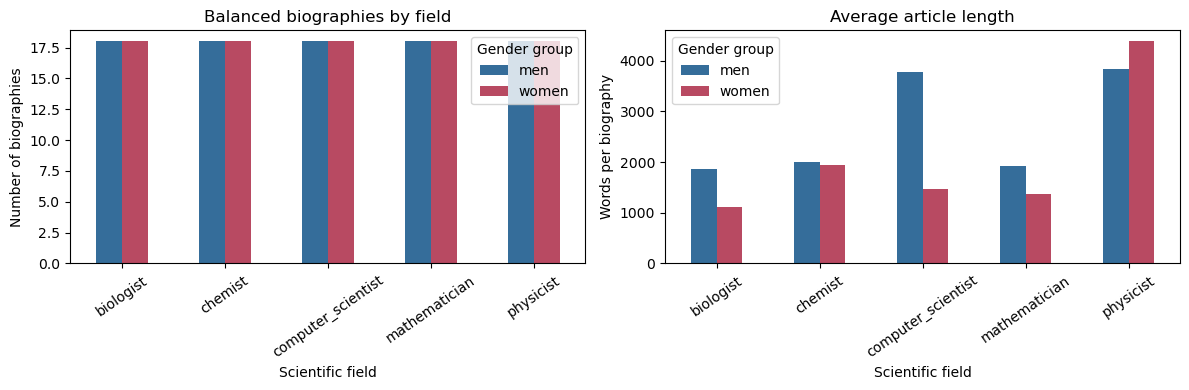

In [47]:
import matplotlib.pyplot as plt

field_counts = balanced_people.groupby(["field", "gender_group"]).size().unstack()
field_lengths = balanced_people.groupby(["field", "gender_group"])["word_count"].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

field_counts.plot(kind="bar", ax=axes[0], color=["#356d9a", "#b84a62"])
axes[0].set_title("Balanced biographies by field")
axes[0].set_xlabel("Scientific field")
axes[0].set_ylabel("Number of biographies")
axes[0].legend(title="Gender group")

field_lengths.plot(kind="bar", ax=axes[1], color=["#356d9a", "#b84a62"])
axes[1].set_title("Average article length")
axes[1].set_xlabel("Scientific field")
axes[1].set_ylabel("Words per biography")
axes[1].legend(title="Gender group")

for ax in axes:
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

The balanced sample contains 180 biographies: 90 biographies of women scientists and 90 biographies of men scientists. Each of the five fields contributes 18 women and 18 men.

Even after balancing article counts, the text volume is not equal. The women’s biographies contain about 162,000 cleaned words, while the men’s biographies contain about 218,000 cleaned words. This means that raw counts are misleading: longer article groups naturally produce more words, paragraphs and co-occurrences. It is for this reason, that later analyses use normalized measures such as mentions per 1,000 words and edges per 100 paragraphs.

## Text Cleaning and Preprocessing

Before analyzing the biographies, we clean the text.

The cleaning process:
- removes reference-like sections such as “References” and “External links,”
- removes the scientist’s own name from their article text,
- lowercases the text,
- removes punctuation and numbers,
- removes common English stopwords and Wikipedia-specific noise words.

This step is necessary because raw Wikipedia text contains many repeated structures and elements that aren't meaningful for our research question.

In [ ]:
# ### for reruns without calling api again:
# import numpy as np
# import matplotlib.pyplot as plt
# import pandas as pd

# people_filtered = pd.read_csv("scientist_biographies_wikipedia.csv")
# balanced_people = pd.read_csv("balanced_scientist_biographies_wikipedia.csv")

# print("Loaded filtered dataset:", people_filtered.shape)
# print("Loaded balanced dataset:", balanced_people.shape)
# print(balanced_people.groupby(["field", "gender_group"]).size())

In [23]:
import re
import itertools
import pandas as pd
import networkx as nx

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# balanced_people = pd.read_csv("balanced_scientist_biographies_wikipedia.csv")

def remove_bad_sections(text):
    bad_sections = {
        "references",
        "bibliography",
        "further reading",
        "external links",
        "see also",
        "notes",
        "sources",
        "works cited",
        "selected publications",
        "publications",
        "books",
        "awards and honors"
    }

    lines = str(text).split("\n")
    keep_lines = []
    skip = False

    for line in lines:
        clean_line = line.strip().lower()

        if clean_line.startswith("==") and clean_line.endswith("=="):
            section_name = clean_line.replace("=", "").strip()

            if section_name in bad_sections:
                skip = True
                continue
            else:
                skip = False

        if not skip:
            keep_lines.append(line)

    return "\n".join(keep_lines)


def remove_title_words(text, title):
    title_words = re.sub(r"[^a-zA-Z\s]", " ", str(title)).lower().split()

    for word in title_words:
        if len(word) > 2:
            text = re.sub(rf"\b{word}\b", " ", text, flags=re.IGNORECASE)

    return text

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"==.*?==", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


CUSTOM_STOPWORDS = set(ENGLISH_STOP_WORDS).union({
    "isbn", "doi", "pmid", "retrieved", "archive", "archived",
    "http", "https", "www", "org", "com",
    "der", "die", "das", "und", "von", "zur", "mit",
    "said", "called", "known", "including",
    "life", "year", "years", "time", "new", "world",
    "born", "died", "early", "later", "people",
    "work", "works", "published", "wikipedia", "th"
})


balanced_people["text_clean_sections"] = balanced_people["text"].apply(remove_bad_sections)

balanced_people["text_no_names"] = balanced_people.apply(
    lambda row: remove_title_words(row["text_clean_sections"], row["title"]),
    axis=1
)

balanced_people["clean_text"] = balanced_people["text_no_names"].apply(clean_text)

# 3. Analysis: Semantics and Network
After preprocessing, we move from simple text patterns to more rigorous analysis. The main idea is not only which words appear, but also how concepts are connected in biographies of women and men scientists. We validate our findings with a statistical test.

Our workflow is:

**Wikidata query → Wikipedia text extraction → filtering → matched sample → text cleaning → TF-IDF/log-odds → thematic clusters → co-occurrence networks → permutation tests → interpretation**

Each method answers a slightly different question and can be split up into three parts

### Semantic

The descriptive statistical insights from the dataset provided some insights into how there were differences in our dataset in terms of volume. Analyzing the contents of the Wikipedia articles can help discern lexical and thematic gaps. Here we utilize TF-IDF for words that are representative of the corpus, with Log-odds ratios to compare gender groups more directly. Bigrams serve to help add context into the qualitative nature of the texts.

Unique words may be highly attributable to specific individuals but sparsely populate the remaining texts. This may overemphasize semantic gender gaps. Here, thematic groupings of words can help with balancing this phenomenon, which we have grouped by family vs science. We hypothesized that this categorical distinction would be the most distinct of all.

### Network

Co-occurrence networks allow us to delv into the underlying semantic structure. Here, words are nodes, and words are connected if they appear in the same paragraph. This helps us study whether biographies organize concepts differently, not just whether they use different words. 

### Statistical test

Finally, permutation testing is used to check whether the observed differences are larger than what we might expect by chance. Since scientific field matters a lot, we shuffle gender labels within each field rather than across the whole dataset. We also use a Bonferroni correction, so the final conclusions stay conservative as alpha values are adjusted accordingly.

Overall, the analysis moves from vocabulary → themes → networks → statistical testing. This lets us explore possible gendered framing in Wikipedia biographies, while still being careful not to overclaim.

## TF-IDF and Gender-Specific Words

We use TF-IDF to identify words that are important in the biography corpus.

TF-IDF stands for **term frequency-inverse document frequency**. It gives higher scores to words that are appearing often in some documents but are not common everywhere. This helps ud identify words that are more distinctive than ordinary frequent words.

The shared TF-IDF vocabulary is used for the word networks. We also add a small gender-specific log-odds comparison to show which words are relatively more characteristic of the women's or men's biographies in this balanced sample.

In [24]:
def get_top_tfidf_words(texts, max_features=200):
    vectorizer = TfidfVectorizer(
        stop_words=list(CUSTOM_STOPWORDS),
        min_df=2,
        max_df=0.6,
        max_features=max_features
    )

    tfidf_matrix = vectorizer.fit_transform(texts)
    words = vectorizer.get_feature_names_out()
    mean_scores = tfidf_matrix.mean(axis=0).A1

    tfidf_df = pd.DataFrame({
        "word": words,
        "tfidf_score": mean_scores
    }).sort_values("tfidf_score", ascending=False)

    return tfidf_df, set(tfidf_df["word"])


tfidf_df, shared_vocab = get_top_tfidf_words(
    balanced_people["clean_text"],
    max_features=200
)

print("Top shared TF-IDF words:")
print(tfidf_df.head(30))

Top shared TF-IDF words:
            word  tfidf_score
30      computer     0.089399
25     chemistry     0.084585
71        german     0.075735
15        berlin     0.070777
90     institute     0.059680
4       american     0.057913
181       theory     0.057048
138      physics     0.056254
114  mathematics     0.052904
195        women     0.051593
11         award     0.050766
153       school     0.048849
72       germany     0.047104
154     sciences     0.046639
180   technology     0.045928
122        named     0.044698
0        academy     0.044524
155   scientific     0.043886
28       college     0.043277
188          war     0.042639
24      chemical     0.041783
142        prize     0.041760
123     national     0.039960
17          book     0.039605
177        study     0.039235
186         used     0.039083
29       company     0.038943
176      studies     0.038489
46      director     0.037976
97    laboratory     0.037722


TF-IDF and log-odds answer different questions. TF-IDF identifies words that are important across the corpus while reducing the influence of very common words. Log-odds compares relative word use between womens and men's biographies.

For a word or phrase, the log-odds comparison can be read as:

$$
\log\left(\frac{p(\text{word} \mid \text{women})}{p(\text{word} \mid \text{men})}\right)
$$

Positive values indicate words more associated with women’s biographies; negative values indicate words more associated with men’s biographies. These results are merely descriptive and can be affected by the individual biographies, names, institutions as well as historical context.

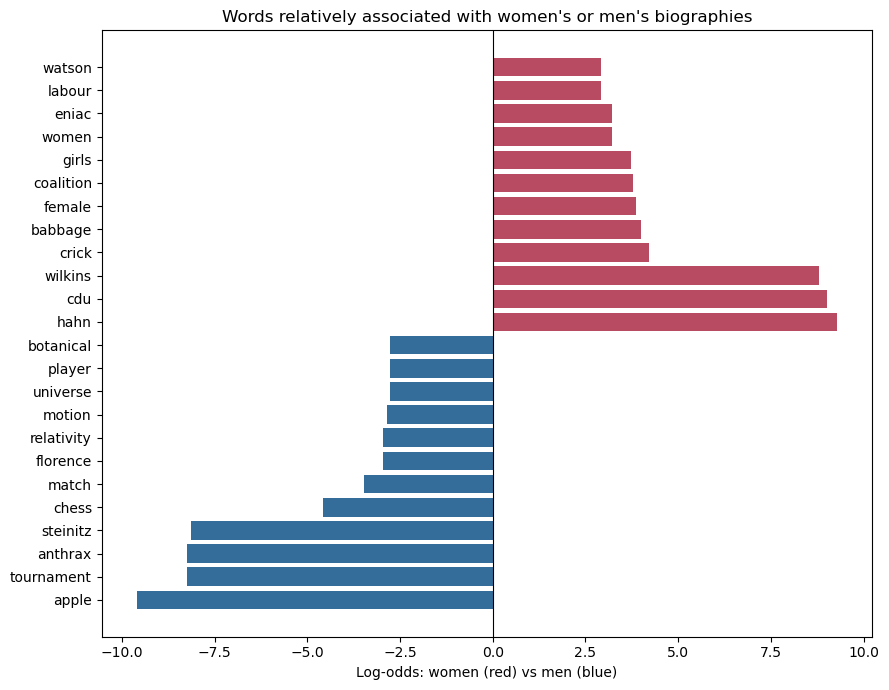

,word,women_count,men_count,log_odds_women_vs_men
389,hahn,94,0,9.289295
122,cdu,71,0,9.008714
982,wilkins,58,0,8.806509
199,crick,59,1,4.208480
76,babbage,48,1,4.002182
320,female,83,2,3.861550
151,coalition,38,1,3.768622
369,girls,36,1,3.714570
986,women,324,15,3.212781
283,eniac,107,5,3.202210


In [52]:
from sklearn.feature_extraction.text import CountVectorizer


def gender_log_odds(df, max_features=1000, alpha=0.01):
    vectorizer = CountVectorizer(
        stop_words=list(CUSTOM_STOPWORDS),
        min_df=2,
        max_features=max_features
    )
    counts_matrix = vectorizer.fit_transform(df["clean_text"])
    words = vectorizer.get_feature_names_out()

    women_mask = df["gender_group"].eq("women").to_numpy()
    men_mask = df["gender_group"].eq("men").to_numpy()

    women_counts = counts_matrix[women_mask].sum(axis=0).A1
    men_counts = counts_matrix[men_mask].sum(axis=0).A1

    vocab_size = len(words)
    women_rates = (women_counts + alpha) / (women_counts.sum() + alpha * vocab_size)
    men_rates = (men_counts + alpha) / (men_counts.sum() + alpha * vocab_size)

    return pd.DataFrame({
        "word": words,
        "women_count": women_counts,
        "men_count": men_counts,
        "log_odds_women_vs_men": np.log(women_rates / men_rates)
    }).sort_values("log_odds_women_vs_men", ascending=False)


gender_words = gender_log_odds(balanced_people)

top_women_words = gender_words.head(12)
top_men_words = gender_words.tail(12).sort_values("log_odds_women_vs_men")
plot_words = pd.concat([top_men_words, top_women_words])

fig, ax = plt.subplots(figsize=(9, 7))
colors = plot_words["log_odds_women_vs_men"].apply(
    lambda value: "#b84a62" if value > 0 else "#356d9a"
)
ax.barh(plot_words["word"], plot_words["log_odds_women_vs_men"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Words relatively associated with women's or men's biographies")
ax.set_xlabel("Log-odds: women (red) vs men (blue)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

gender_words.to_csv("gender_log_odds_words.csv", index=False)
gender_words.head(10)

### Document Frequency by Gender

We can check if the results above were simply skewed by overrepresentative biographies

In [26]:
def document_frequency_by_gender(df, terms, text_col="clean_text"):
    rows = []

    for term in terms:
        pattern = rf"\b{re.escape(term)}\b"

        for gender in ["women", "men"]:
            group = df[df["gender_group"].eq(gender)]
            doc_count = group[text_col].str.contains(pattern, regex=True).sum()

            rows.append({
                "term": term,
                "gender_group": gender,
                "biographies_containing_term": doc_count,
                "total_biographies": len(group),
                "share_of_biographies": doc_count / len(group)
            })

    return pd.DataFrame(rows)


top_terms = pd.concat([
    gender_words.head(10)["word"],
    gender_words.tail(10)["word"]
]).unique()

term_document_check = document_frequency_by_gender(balanced_people, top_terms)

display(term_document_check)

term_document_check.to_csv("log_odds_term_document_check.csv", index=False)

,term,gender_group,biographies_containing_term,total_biographies,share_of_biographies
0,hahn,women,2,90,0.022222
1,hahn,men,0,90,0.000000
2,cdu,women,3,90,0.033333
3,cdu,men,0,90,0.000000
4,wilkins,women,2,90,0.022222
5,wilkins,men,0,90,0.000000
6,crick,women,3,90,0.033333
7,crick,men,1,90,0.011111
8,babbage,women,4,90,0.044444
9,babbage,men,1,90,0.011111


This check helps identify whether distinctive words are broad framing patterns or artifacts of a few biographies. Some words, such as “women,” “female,” and “girls,” occur across many women’s biographies and are thereforre more interpretable as group-level framing signals. Other words, such as specific surnames, institutions, or political terms, appear in only a few biographies and should be treated as sample-composition artifacts rather than general evidence of gendered framing.

## Bigram Collocations

Single words can be difficult to interpret because they lack context. To make the framing analysis more readable, we also explore common two-word phrases, or bigrams, that are relatively more common in women's or men's biographies.

This section is descriptive and part of the process of uncovering the underlying data. It is used to interpret the word-level results, while the permutation test focuses on predefined theme and network measures.

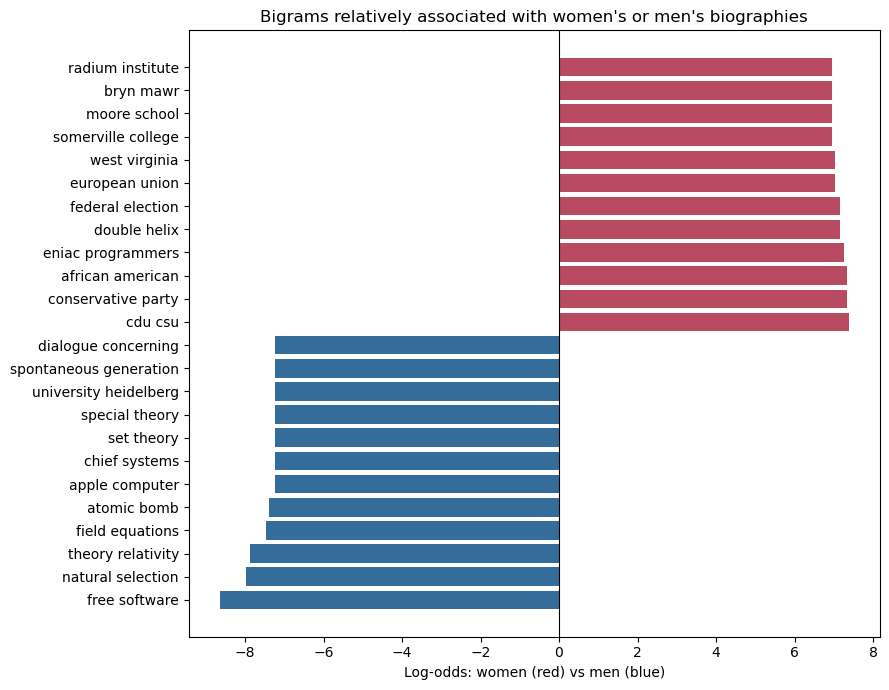

,bigram,women_count,men_count,log_odds_women_vs_men
66,cdu csu,20,0,7.377698
97,conservative party,19,0,7.326431
12,african american,19,0,7.326431
139,eniac programmers,18,0,7.272393
125,double helix,16,0,7.154680
151,federal election,16,0,7.154680
145,european union,14,0,7.021238
478,west virginia,14,0,7.021238
410,somerville college,13,0,6.947185
272,moore school,13,0,6.947185


In [53]:
def gender_bigram_log_odds(df, max_features=500, alpha=0.01):
    vectorizer = CountVectorizer(
        stop_words=list(CUSTOM_STOPWORDS),
        min_df=2,
        max_features=max_features,
        ngram_range=(2, 2)
    )

    counts_matrix = vectorizer.fit_transform(df["clean_text"])
    bigrams = vectorizer.get_feature_names_out()

    women_mask = df["gender_group"].eq("women").to_numpy()
    men_mask = df["gender_group"].eq("men").to_numpy()

    women_counts = counts_matrix[women_mask].sum(axis=0).A1
    men_counts = counts_matrix[men_mask].sum(axis=0).A1

    vocab_size = len(bigrams)
    women_rates = (women_counts + alpha) / (women_counts.sum() + alpha * vocab_size)
    men_rates = (men_counts + alpha) / (men_counts.sum() + alpha * vocab_size)

    return pd.DataFrame({
        "bigram": bigrams,
        "women_count": women_counts,
        "men_count": men_counts,
        "log_odds_women_vs_men": np.log(women_rates / men_rates)
    }).sort_values("log_odds_women_vs_men", ascending=False)


bigram_words = gender_bigram_log_odds(balanced_people)

top_women_bigrams = bigram_words.head(12)
top_men_bigrams = bigram_words.tail(12).sort_values("log_odds_women_vs_men")
plot_bigrams = pd.concat([top_men_bigrams, top_women_bigrams])

fig, ax = plt.subplots(figsize=(9, 7))

colors = plot_bigrams["log_odds_women_vs_men"].apply(
    lambda value: "#b84a62" if value > 0 else "#356d9a"
)

ax.barh(plot_bigrams["bigram"], plot_bigrams["log_odds_women_vs_men"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Bigrams relatively associated with women's or men's biographies")
ax.set_xlabel("Log-odds: women (red) vs men (blue)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

bigram_words.to_csv("gender_bigram_log_odds.csv", index=False)
bigram_words.head(10)

In [42]:
def document_frequency_by_gender_for_phrases(df, phrases, text_col="clean_text"):
    rows = []

    for phrase in phrases:
        pattern = rf"\b{re.escape(phrase)}\b"

        for gender in ["women", "men"]:
            group = df[df["gender_group"].eq(gender)]
            doc_count = group[text_col].str.contains(pattern, regex=True).sum()

            rows.append({
                "phrase": phrase,
                "gender_group": gender,
                "biographies_containing_phrase": doc_count,
                "total_biographies": len(group),
                "share_of_biographies": doc_count / len(group)
            })

    return pd.DataFrame(rows)


top_bigrams = pd.concat([
    bigram_words.head(10)["bigram"],
    bigram_words.tail(10)["bigram"]
]).unique()

bigram_document_check = document_frequency_by_gender_for_phrases(
    balanced_people,
    top_bigrams
)

display(bigram_document_check)

bigram_document_check.to_csv("bigram_document_frequency_check.csv", index=False)

,phrase,gender_group,biographies_containing_phrase,total_biographies,share_of_biographies
0,cdu csu,women,2,90,0.022222
1,cdu csu,men,0,90,0.000000
2,conservative party,women,2,90,0.022222
3,conservative party,men,0,90,0.000000
4,african american,women,2,90,0.022222
5,african american,men,0,90,0.000000
6,eniac programmers,women,5,90,0.055556
7,eniac programmers,men,0,90,0.000000
8,double helix,women,2,90,0.022222
9,double helix,men,0,90,0.000000


Here we see that bigram collocations are more prone to being sparsely and uniquely associated with small clusters 

## Thematic Clusters (Family-Science)

To reduce signal-to-noise, it is useful to group words by higher order categories. Here we have chosen to focus on science vs family. This choice was based on the large degree with which the most well regarded findings on gender disparities are found within the phenomenon of interest in things vs people. This is the most reproducible gender difference in psychometric literature, ranging from toy studies to differences in occupational choice. Therefore, it would be interesting to see if such effects would be suppressed in STEM-biographies, which is traditionally a male-dominated field. 

Given that these are all biographies in the sciences with balanced gender sample populations, then the relevance of the aforementioned literature may very well be supressed. 

The choice of which words to include in family and science were chosen via a Large Language Model (GPT-5.5), due to the model's semantic vector space embeddings of words as a proxy, however more robust methods of finding semantic neighbors are possible.

,gender_group,cluster,mentions,clean_words,mentions_per_1000_words
0,men,family,1019,217596,4.682990
1,men,science,3624,217596,16.654718
2,women,family,991,162118,6.112831
3,women,science,4001,162118,24.679554


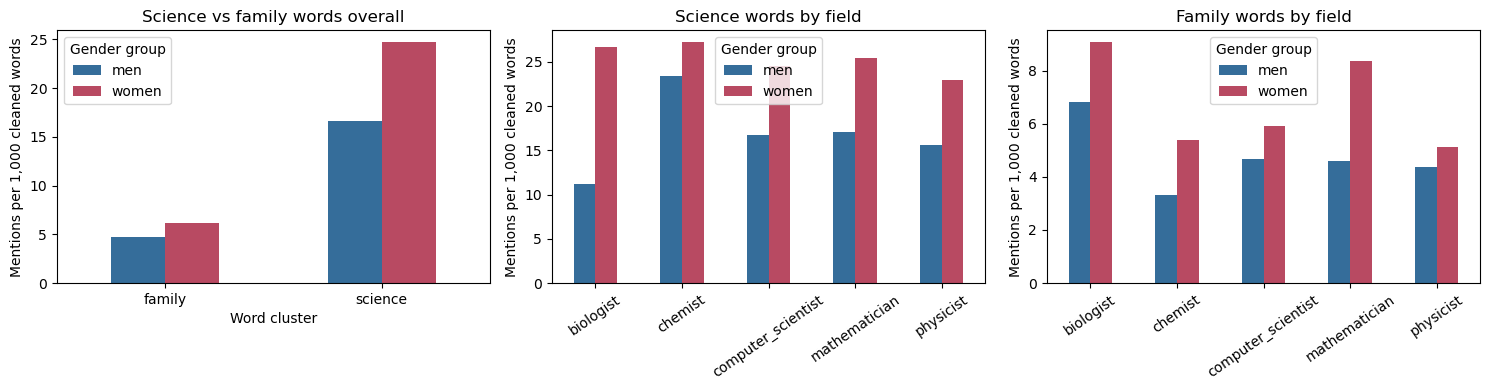

In [57]:
SCIENCE_WORDS = {
    "science", "scientific", "research", "researcher", "theory", "theoretical",
    "experiment", "experiments", "laboratory", "lab", "paper", "papers",
    "publication", "publications", "physics", "chemistry", "biology",
    "mathematics", "computer", "engineering", "technology", "discovery",
    "award", "prize", "medal", "professor", "university"
}

FAMILY_WORDS = {
    "family", "father", "mother", "parent", "parents", "wife", "husband",
    "married", "marriage", "spouse", "son", "sons", "daughter", "daughters",
    "child", "children", "brother", "sister", "home"
}

WORD_CLUSTERS = {
    "science": SCIENCE_WORDS,
    "family": FAMILY_WORDS
}


def count_cluster_words(text, cluster_words):
    tokens = str(text).split()
    counts = Counter(tokens)
    return sum(counts[word] for word in cluster_words)


cluster_rows = []

for _, row in balanced_people.iterrows():
    clean_words = max(len(str(row["clean_text"]).split()), 1)

    for cluster, words in WORD_CLUSTERS.items():
        mentions = count_cluster_words(row["clean_text"], words)
        cluster_rows.append({
            "field": row["field"],
            "gender_group": row["gender_group"],
            "cluster": cluster,
            "mentions": mentions,
            "clean_words": clean_words
        })

cluster_counts = pd.DataFrame(cluster_rows)

cluster_summary = (
    cluster_counts
    .groupby(["gender_group", "cluster"], as_index=False)
    .agg(mentions=("mentions", "sum"), clean_words=("clean_words", "sum"))
)
cluster_summary["mentions_per_1000_words"] = (
    1000 * cluster_summary["mentions"] / cluster_summary["clean_words"]
)

field_cluster_summary = (
    cluster_counts
    .groupby(["field", "gender_group", "cluster"], as_index=False)
    .agg(mentions=("mentions", "sum"), clean_words=("clean_words", "sum"))
)
field_cluster_summary["mentions_per_1000_words"] = (
    1000 * field_cluster_summary["mentions"] / field_cluster_summary["clean_words"]
)

display(cluster_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cluster_summary.pivot(
    index="cluster",
    columns="gender_group",
    values="mentions_per_1000_words"
).plot(kind="bar", ax=axes[0], color=["#356d9a", "#b84a62"])
axes[0].set_title("Science vs family words overall")
axes[0].set_xlabel("Word cluster")
axes[0].set_ylabel("Mentions per 1,000 cleaned words")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Gender group")

for ax, cluster in zip(axes[1:], ["science", "family"]):
    data = field_cluster_summary[field_cluster_summary["cluster"].eq(cluster)]
    data.pivot(
        index="field",
        columns="gender_group",
        values="mentions_per_1000_words"
    ).plot(kind="bar", ax=ax, color=["#356d9a", "#b84a62"])
    ax.set_title(f"{cluster.title()} words by field")
    ax.set_xlabel("")
    ax.set_ylabel("Mentions per 1,000 cleaned words")
    ax.tick_params(axis="x", rotation=35)
    ax.legend(title="Gender group")

plt.tight_layout()
plt.show()

cluster_summary.to_csv("science_family_cluster_summary.csv", index=False)
field_cluster_summary.to_csv("science_family_cluster_by_field.csv", index=False)

Female biographies in this sample have higher normalized rates of both family-related and science-related vocabulary. This suggests that women’s pages may contain denser references to both personal life and scientific achievement, although this may partly reflect article style, biography length, or the chosen keyword lists.

## Building Word Co-occurrence Networks

This section instantiates networks from the biographical text.

In these networks:
- each node is an important word,
- an edge connects two words if they appear in the same paragraph,
- edge weight counts how often the two words co-occur.

We build one network for biographies of women scientists and one for biographies of men scientists. The goal is to compare whether the two sets of biographies organize concepts differently.

Important limitation: network measures can still be affected by article length, paragraph structure, and sample composition. To reduce this problem, the analysis reports normalized edge counts and uses within-field permutation tests, but the network results should still be interpreted as exploratory.

Formally, each network is a weighted undirected graph:

$$
G = (V, E)
$$

where nodes $V$ are words and edges $E$ connect words that co-occur in the same paragraph. Edge weights count how many times a pair of words co-occurs.

The main network measures are:

- **Weighted degree**: the total strength of a word’s connections, $s_i = \sum_j w_{ij}$. High weighted-degree words are central themes/concepts in the semantic network.
- **Density**: the share of possible word-word connections that actually exist, $D = \frac{2m}{n(n-1)}$. Higher density means the vocabulary is more broadly interconnected.
- **Clustering**: the tendency for a words neighbors to connect with each other. In text networks, clustering suggests locally coherent themes.
- **Communities**: groups of words that are more interconnected than the rest of the network. These can be interpreted as rough approximations of semantic clusteringss.



### Why we used word networks

We used word co-occurrence networks because we wanted to look at more than just word counts. Word counts show which words appear often, but networks show how words are connected to each other in the biographies.

In our network, each node is a word, and edges connect words that appear in the same context. The idea is that words that often appear together can point to a shared theme or framing. For example, science words may cluster around research, institutions, fields, and discoveries, while personal words may cluster around family or relationships.

This is useful for our project because we are studying how Wikipedia biographies frame scientists. If certain words are more central or more connected in one gender group, that can suggest that those biographies organize the scientist’s story differently. We also considered using links between Wikipedia articles as our network. However, for our research question, we found word co-occurrence networks more useful. Article links show explicit connections chosen by Wikipedia editors, but words contain more local information inside each biography. They work almost like "unclickable concepts": small semantic signals that show how the scientist is contextualized.

Because our project is about language and framing, word networks were therefore a better fit than hyperlink networks.
We used weighted degree to see which words were most connected in the network. We used density and clustering to compare how tightly connected the word networks were overall. Edge weights were included because repeated word connections are more meaningful than one-time co-occurrences.

In [29]:
def split_into_paragraphs(text):
    paragraphs = str(text).split("\n")
    paragraphs = [p.strip() for p in paragraphs if len(p.strip()) > 80]
    return paragraphs


def build_cooccurrence_network(df, vocabulary, min_words=2, max_words=15):
    G = nx.Graph()

    edge_weights = Counter()
    node_counts = Counter()

    for _, row in df.iterrows():
        paragraphs = split_into_paragraphs(row["text_no_names"])

        for paragraph in paragraphs:
            clean_paragraph = clean_text(paragraph)
            words = clean_paragraph.split()

            words = [
                w for w in words
                if w in vocabulary and w not in CUSTOM_STOPWORDS
            ]

            unique_words = sorted(set(words))

            # Avoid paragraphs that are too sparse or too dense
            if len(unique_words) < min_words or len(unique_words) > max_words:
                continue

            for word in unique_words:
                node_counts[word] += 1

            for w1, w2 in itertools.combinations(unique_words, 2):
                edge_weights[(w1, w2)] += 1

    for word, count in node_counts.items():
        G.add_node(word, paragraph_count=count)

    for (w1, w2), weight in edge_weights.items():
        G.add_edge(w1, w2, weight=weight)

    return G


def remove_weak_edges(G, min_weight=2):
    weak_edges = [
        (u, v)
        for u, v, d in G.edges(data=True)
        if d["weight"] < min_weight
    ]

    G.remove_edges_from(weak_edges)
    G.remove_nodes_from(list(nx.isolates(G)))

    return G


women_df = balanced_people[balanced_people["gender_group"] == "women"].copy()
men_df = balanced_people[balanced_people["gender_group"] == "men"].copy()

G_women = build_cooccurrence_network(women_df, shared_vocab)
G_men = build_cooccurrence_network(men_df, shared_vocab)

G_women = remove_weak_edges(G_women, min_weight=2)
G_men = remove_weak_edges(G_men, min_weight=2)

## Network Comparison

For each word network, we report nodes, edges, density, clustering, weighted degree, and the most central words by weighted degree.

We also normalize edge counts by paragraph count and compare observed clustering with random graphs that have the same number of nodes and edges. This gives a simple null-model check for whether the network is more clustered than expected from size alone.

,Group,Articles,Paragraphs,Nodes,Edges,Edges / 100 paragraphs,Density,Clustering,Clustering z-score
0,Women,90,2306,198,9488,411.448,0.486,0.630,238.953
1,Men,90,2864,200,10295,359.462,0.517,0.659,217.003


,word,weighted_degree,network
0,women,1323,Women
1,chemistry,1249,Women
2,college,1108,Women
3,american,1076,Women
4,school,937,Women
5,institute,921,Women
6,computer,846,Women
7,national,834,Women
8,did,810,Women
9,woman,791,Women


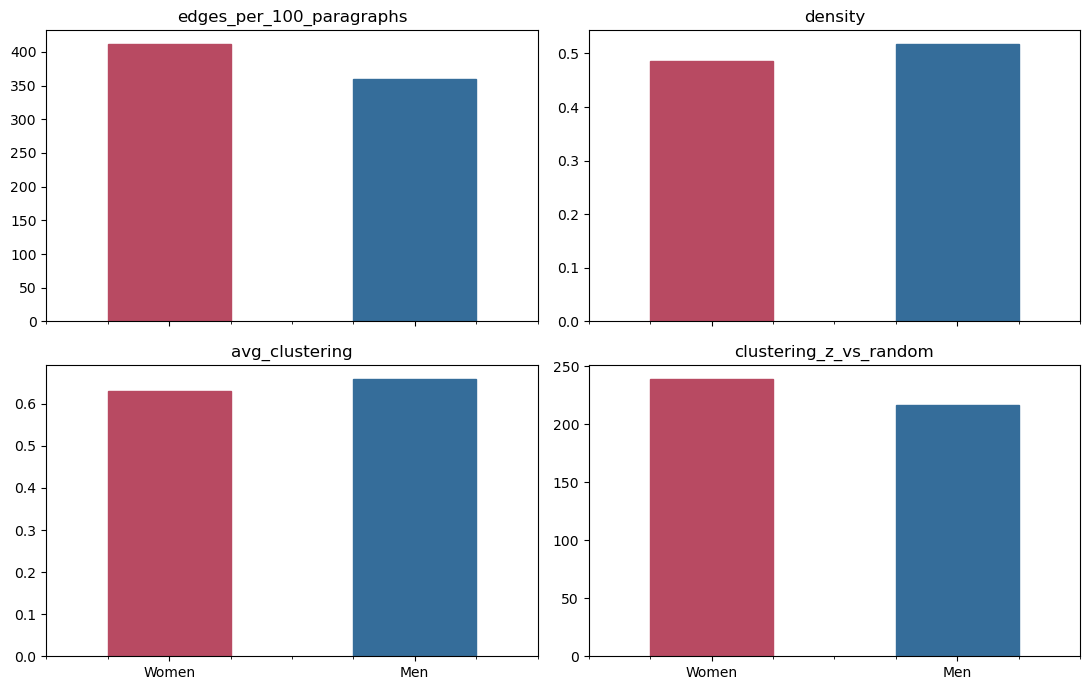


Saved files:
women_scientists_semantic_network_cleaned.gexf
men_scientists_semantic_network_cleaned.gexf
shared_tfidf_words_cleaned.csv
gender_log_odds_words.csv
network_metrics_cleaned.csv
top_network_words_cleaned.csv


In [59]:
def top_weighted_degree(G, name, n=15):
    weighted_degrees = dict(G.degree(weight="weight"))
    return pd.DataFrame(
        sorted(weighted_degrees.items(), key=lambda x: x[1], reverse=True)[:n],
        columns=["word", "weighted_degree"]
    ).assign(network=name)


def random_clustering_baseline(G, runs=100, seed=42):
    if G.number_of_nodes() < 3 or G.number_of_edges() == 0:
        return np.nan, np.nan, np.nan

    observed = nx.average_clustering(G)
    random_scores = []

    for i in range(runs):
        R = nx.gnm_random_graph(
            G.number_of_nodes(),
            G.number_of_edges(),
            seed=seed + i
        )
        random_scores.append(nx.average_clustering(R))

    random_mean = np.mean(random_scores)
    random_std = np.std(random_scores)
    z_score = (observed - random_mean) / random_std if random_std > 0 else np.nan

    return random_mean, random_std, z_score


def network_metrics(G, df, name):
    paragraph_count = sum(len(split_into_paragraphs(text)) for text in df["text_no_names"])
    degrees = dict(G.degree())
    weighted_degrees = dict(G.degree(weight="weight"))
    communities = list(nx.community.greedy_modularity_communities(G, weight="weight")) if G.number_of_edges() else []
    random_clustering_mean, random_clustering_std, clustering_z = random_clustering_baseline(G)

    return {
        "network": name,
        "articles": len(df),
        "paragraphs": paragraph_count,
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "edges_per_100_paragraphs": 100 * G.number_of_edges() / max(paragraph_count, 1),
        "density": nx.density(G) if G.number_of_nodes() > 1 else 0,
        "avg_degree": np.mean(list(degrees.values())) if degrees else 0,
        "avg_weighted_degree": np.mean(list(weighted_degrees.values())) if weighted_degrees else 0,
        "avg_clustering": nx.average_clustering(G) if G.number_of_nodes() > 1 else 0,
        "communities": len(communities),
        "random_clustering_mean": random_clustering_mean,
        "clustering_z_vs_random": clustering_z
    }


network_metrics_df = pd.DataFrame([
    network_metrics(G_women, women_df, "Women"),
    network_metrics(G_men, men_df, "Men")
])

display_table = network_metrics_df[[
    "network",
    "articles",
    "paragraphs",
    "nodes",
    "edges",
    "edges_per_100_paragraphs",
    "density",
    "avg_clustering",
    "clustering_z_vs_random"
]].round(3)

display_table = display_table.rename(columns={
    "network": "Group",
    "articles": "Articles",
    "paragraphs": "Paragraphs",
    "nodes": "Nodes",
    "edges": "Edges",
    "edges_per_100_paragraphs": "Edges / 100 paragraphs",
    "density": "Density",
    "avg_clustering": "Clustering",
    "clustering_z_vs_random": "Clustering z-score"
})

display(display_table)

top_nodes = pd.concat([
    top_weighted_degree(G_women, "Women"),
    top_weighted_degree(G_men, "Men")
])
display(top_nodes)

plot_metrics = network_metrics_df.set_index("network")[[
    "edges_per_100_paragraphs",
    "density",
    "avg_clustering",
    "clustering_z_vs_random"
]]

axes = plot_metrics.plot(
    kind="bar",
    subplots=True,
    layout=(2, 2),
    figsize=(11, 7),
    legend=False,
)
for ax in axes.flatten():
    for bar, group in zip(ax.patches, plot_metrics.index):
        bar.set_color("#b84a62" if group == "Women" else "#356d9a")

for ax in axes.flatten():
    ax.tick_params(axis="x", rotation=0)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

nx.write_gexf(G_women, "women_scientists_semantic_network_cleaned.gexf")
nx.write_gexf(G_men, "men_scientists_semantic_network_cleaned.gexf")

tfidf_df.to_csv("shared_tfidf_words_cleaned.csv", index=False)
network_metrics_df.to_csv("network_metrics_cleaned.csv", index=False)
top_nodes.to_csv("top_network_words_cleaned.csv", index=False)

print("\nSaved files:")
print("women_scientists_semantic_network_cleaned.gexf")
print("men_scientists_semantic_network_cleaned.gexf")
print("shared_tfidf_words_cleaned.csv")
print("gender_log_odds_words.csv")
print("network_metrics_cleaned.csv")
print("top_network_words_cleaned.csv")

## Graph Visualization

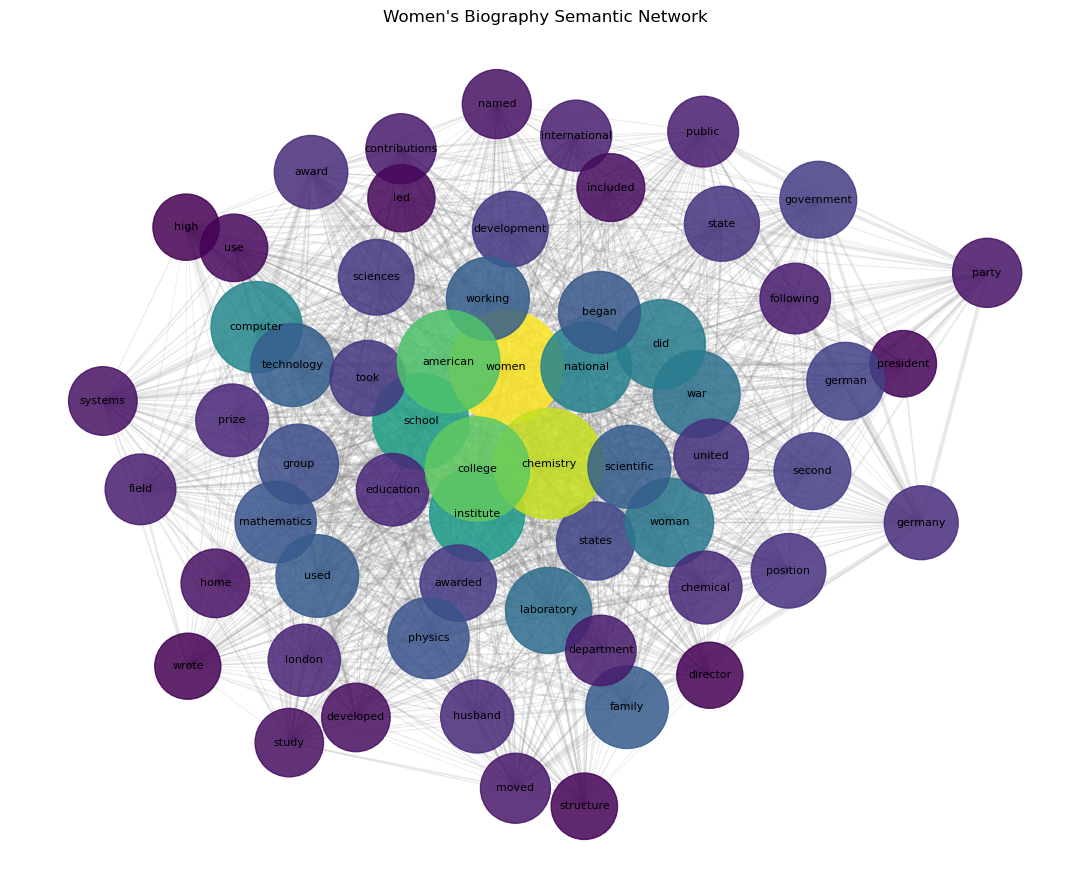

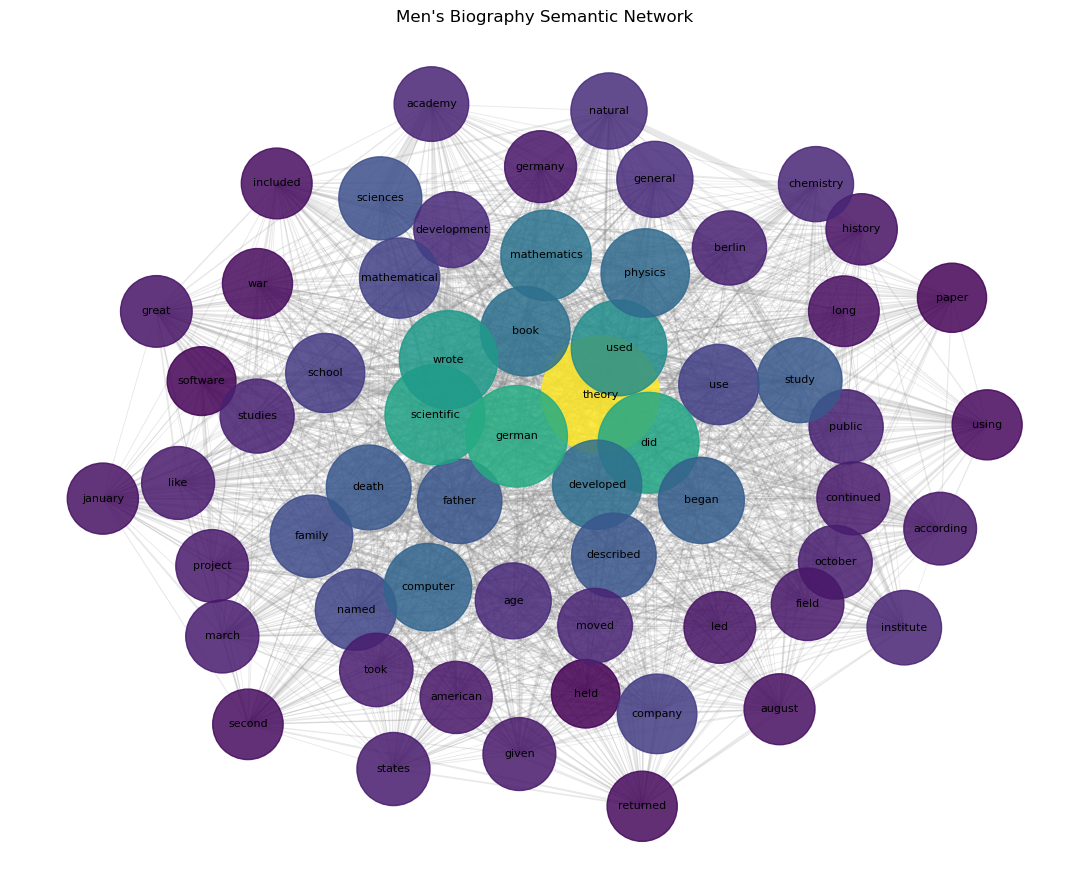

In [38]:
def plot_pretty_gexf_network(path, title, top_n=60):
    G = nx.read_gexf(path)

    weighted_degree = dict(G.degree(weight="weight"))
    top_nodes = [
        node for node, score in
        sorted(weighted_degree.items(), key=lambda x: x[1], reverse=True)[:top_n]
    ]

    H = G.subgraph(top_nodes).copy()
    pos = nx.spring_layout(H, seed=42, weight="weight", k=0.7)

    node_sizes = [
        80 + 5 * weighted_degree[node]
        for node in H.nodes()
    ]

    edge_widths = [
        0.2 + 0.15 * H[u][v].get("weight", 1)
        for u, v in H.edges()
    ]

    plt.figure(figsize=(11, 9))
    nx.draw_networkx_edges(
        H, pos,
        alpha=0.18,
        width=edge_widths,
        edge_color="gray"
    )
    nx.draw_networkx_nodes(
        H, pos,
        node_size=node_sizes,
        node_color=list(node_sizes),
        cmap="viridis",
        alpha=0.85
    )
    nx.draw_networkx_labels(
        H, pos,
        font_size=8,
        font_color="black"
    )

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


plot_pretty_gexf_network(
    "women_scientists_semantic_network_cleaned.gexf",
    "Women's Biography Semantic Network"
)

plot_pretty_gexf_network(
    "men_scientists_semantic_network_cleaned.gexf",
    "Men's Biography Semantic Network"
)

## Bonferroni Corrected Permutation Tests

To evaluate whether observed differences are larger than expected by chance, we use a within-field permutation test. The test keeps the field structure fixed but randomly shuffles gender labels within each field. For every shuffle, the women’s and men’s theme rates and network measures are recomputed.

This creates a null distribution: the differences we would expect if gender labels were random within fields. The observed result is then compared against this null distribution.

Because six outcomes are tested, we also apply a strict Bonferroni correction:

$$
\\alpha_{Bonferroni} = \frac{0.05}{6} = 0.0083
$$

This is conservative. Results that are significant before correction but not after Bonferroni should be described as suggestive rather than conclusive.

,category,metric,observed_women_minus_men,null_mean,p_value_two_sided,direction
0,network,edges_per_100_paragraphs,51.986105,0.436540,0.034965,higher for women
2,network,avg_clustering,-0.028543,-0.001370,0.604396,higher for men
1,network,density,-0.030847,-0.001752,0.683317,higher for men
3,network,avg_weighted_degree,-26.116364,-1.678918,0.765235,higher for men
4,theme,science_words_per_1000,8.024836,-0.028741,0.004995,higher for women
5,theme,family_words_per_1000,1.429841,-0.003086,0.035964,higher for women


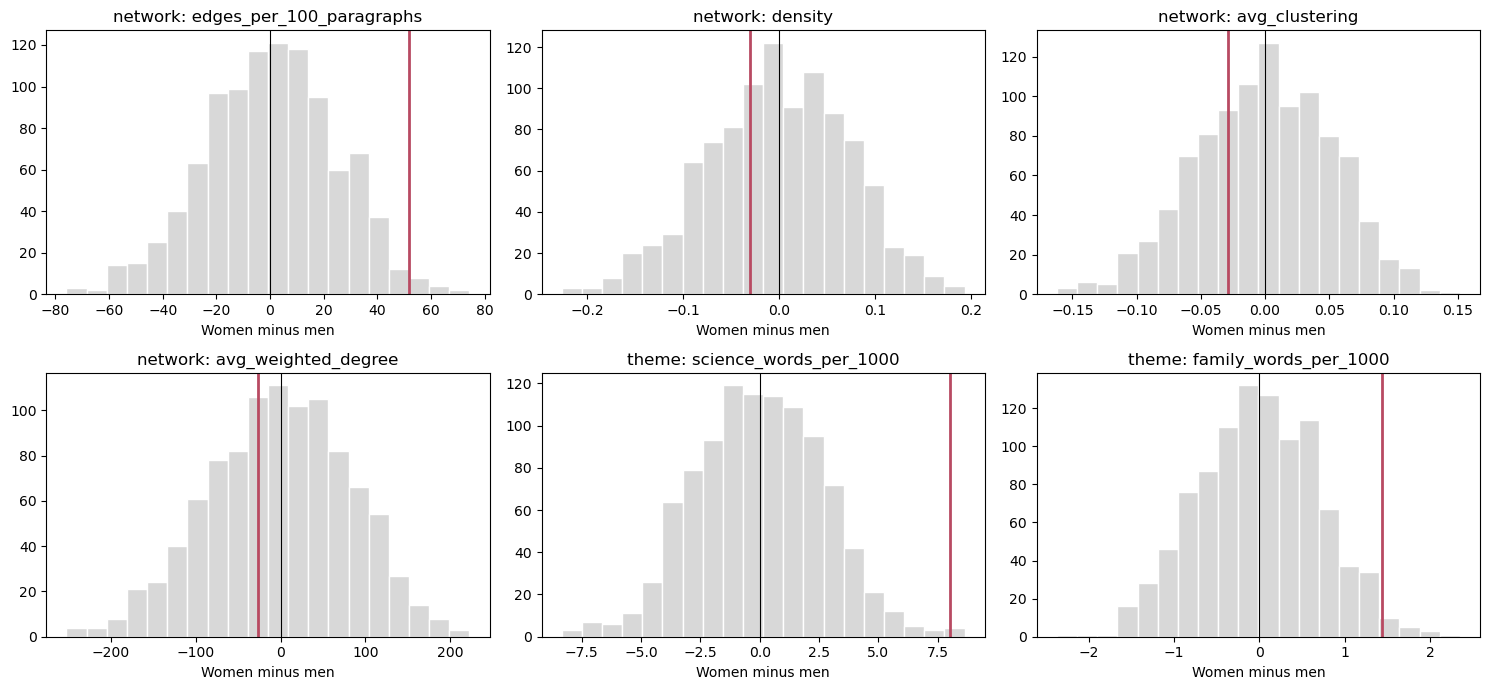

In [39]:

N_PERMUTATIONS = 1000
rng = np.random.default_rng(42)


def quick_network_metrics(G, df):
    paragraph_count = sum(len(split_into_paragraphs(text)) for text in df["text_no_names"])
    weighted_degrees = dict(G.degree(weight="weight"))

    return {
        "edges_per_100_paragraphs": 100 * G.number_of_edges() / max(paragraph_count, 1),
        "density": nx.density(G) if G.number_of_nodes() > 1 else 0,
        "avg_clustering": nx.average_clustering(G) if G.number_of_nodes() > 1 else 0,
        "avg_weighted_degree": np.mean(list(weighted_degrees.values())) if weighted_degrees else 0
    }


def metric_differences(women_values, men_values):
    return {
        metric: women_values[metric] - men_values[metric]
        for metric in women_values
    }


def theme_rate_differences(df, gender_col):
    rates = {}

    for gender in ["women", "men"]:
        group = df[df[gender_col].eq(gender)]
        clean_words = sum(max(len(str(text).split()), 1) for text in group["clean_text"])

        for cluster, words in WORD_CLUSTERS.items():
            mentions = sum(count_cluster_words(text, words) for text in group["clean_text"])
            rates[(gender, cluster)] = 1000 * mentions / max(clean_words, 1)

    return {
        f"{cluster}_words_per_1000": rates[("women", cluster)] - rates[("men", cluster)]
        for cluster in WORD_CLUSTERS
    }


def shuffle_gender_within_fields(df):
    shuffled = df.copy()
    shuffled["permuted_gender"] = shuffled["gender_group"]

    for _, index in shuffled.groupby("field").groups.items():
        labels = shuffled.loc[index, "gender_group"].to_numpy().copy()
        rng.shuffle(labels)
        shuffled.loc[index, "permuted_gender"] = labels

    return shuffled


observed_network = metric_differences(
    quick_network_metrics(G_women, women_df),
    quick_network_metrics(G_men, men_df)
)
observed_theme = theme_rate_differences(balanced_people, "gender_group")

permutation_rows = []

for iteration in range(N_PERMUTATIONS):
    permuted = shuffle_gender_within_fields(balanced_people)

    perm_women = permuted[permuted["permuted_gender"].eq("women")].copy()
    perm_men = permuted[permuted["permuted_gender"].eq("men")].copy()

    perm_G_women = remove_weak_edges(
        build_cooccurrence_network(perm_women, shared_vocab),
        min_weight=2
    )
    perm_G_men = remove_weak_edges(
        build_cooccurrence_network(perm_men, shared_vocab),
        min_weight=2
    )

    network_diff = metric_differences(
        quick_network_metrics(perm_G_women, perm_women),
        quick_network_metrics(perm_G_men, perm_men)
    )
    theme_diff = theme_rate_differences(permuted, "permuted_gender")

    row = {"iteration": iteration}
    row.update({f"network_{metric}": value for metric, value in network_diff.items()})
    row.update({f"theme_{metric}": value for metric, value in theme_diff.items()})
    permutation_rows.append(row)

permutation_results = pd.DataFrame(permutation_rows)

summary_rows = []

for category, observed_values in [("network", observed_network), ("theme", observed_theme)]:
    for metric, observed_difference in observed_values.items():
        column = f"{category}_{metric}"
        null_values = permutation_results[column].to_numpy()
        p_value = (np.sum(np.abs(null_values) >= abs(observed_difference)) + 1) / (N_PERMUTATIONS + 1)

        summary_rows.append({
            "category": category,
            "metric": metric,
            "observed_women_minus_men": observed_difference,
            "null_mean": np.mean(null_values),
            "p_value_two_sided": p_value,
            "direction": "higher for women" if observed_difference > 0 else "higher for men"
        })

permutation_summary = pd.DataFrame(summary_rows).sort_values(["category", "p_value_two_sided"])
display(permutation_summary)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

for ax, row in zip(axes, summary_rows):
    column = f"{row['category']}_{row['metric']}"
    ax.hist(permutation_results[column], bins=20, color="#d8d8d8", edgecolor="white")
    ax.axvline(row["observed_women_minus_men"], color="#b84a62", linewidth=2)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{row['category']}: {row['metric']}")
    ax.set_xlabel("Women minus men")

for ax in axes[len(summary_rows):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

permutation_summary.to_csv("permutation_test_summary.csv", index=False)
permutation_results.to_csv("permutation_test_null_distributions.csv", index=False)

The grey histograms show the null distribution obtained by randomly shuffling gender labels within each scientific field 1000 times. The red vertical line shows the observed women-minus-men difference in the real data, while the black line marks zero difference. If the red line lies far in the tail of the grey distribution, the observed gender difference is unlikely to have arisen by random assignment within fields.

These are the results of our permutation test, however, given the multi-variable nature of our tests, we must correct for the increased probability of finding a random outlier.

## Results

We reduce the alpha threshold with which we accept any of our six statistical hypothesis tests. From an initial alpha of 0.05, we find our corrected p-values to be 0.008333

In [43]:
ALPHA = 0.05

try:
    bonferroni_results = permutation_summary.copy()
except NameError:
    bonferroni_results = pd.read_csv("permutation_test_summary.csv")

n_tests = len(bonferroni_results)
bonferroni_threshold = ALPHA / n_tests

bonferroni_results["bonferroni_threshold"] = bonferroni_threshold
bonferroni_results["significant_bonferroni"] = (
    bonferroni_results["p_value_two_sided"] < bonferroni_threshold
)

bonferroni_display = bonferroni_results[[
    "category",
    "metric",
    "observed_women_minus_men",
    "p_value_two_sided",
    "bonferroni_threshold",
    "significant_bonferroni",
    "direction"
]].copy()

display(bonferroni_display)

print("Number of tests:", n_tests)
print("Bonferroni threshold:", bonferroni_threshold)

print("\nSignificant after strict Bonferroni correction:")
display(
    bonferroni_display[
        bonferroni_display["significant_bonferroni"]
    ]
)

bonferroni_display.to_csv("bonferroni_permutation_summary.csv", index=False)

,category,metric,observed_women_minus_men,p_value_two_sided,bonferroni_threshold,significant_bonferroni,direction
0,network,edges_per_100_paragraphs,51.986105,0.034965,0.008333,False,higher for women
2,network,avg_clustering,-0.028543,0.604396,0.008333,False,higher for men
1,network,density,-0.030847,0.683317,0.008333,False,higher for men
3,network,avg_weighted_degree,-26.116364,0.765235,0.008333,False,higher for men
4,theme,science_words_per_1000,8.024836,0.004995,0.008333,True,higher for women
5,theme,family_words_per_1000,1.429841,0.035964,0.008333,False,higher for women


Number of tests: 6
Bonferroni threshold: 0.008333333333333333

Significant after strict Bonferroni correction:


,category,metric,observed_women_minus_men,p_value_two_sided,bonferroni_threshold,significant_bonferroni,direction
4,theme,science_words_per_1000,8.024836,0.004995,0.008333,True,higher for women


We can see that out of our four network hypothesis tests and two semantic tests we have found one statistically significant finding, namely that woman scientists have more science related words than their male counterparts based on our dataset.

## Conclusion

This project finds suggestive evidence of gendered framing in English Wikipedia science biographies, strongest at the level of thematic word use.

In the balanced sample of 180 biographies, women’s biographies contain higher normalized rates of both science-related words and family-related words. Women’s biographies contain about 24.7 science-theme words per 1,000 cleaned words, compared with about 16.7 for men. They also contain about 6.1 family-theme words per 1,000 cleaned words, compared with about 4.7 for men.

The network results are more mixed. Women’s biography networks show more co-occurrence edges per 100 paragraphs, while men’s networks have slightly higher density, weighted degree, and clustering. However, the permutation tests do not show robust network differences after strict Bonferroni correction.

Our strongest results have shown that science related words are more represented in woman scientist Wikipedia articles than men. This does not necessarily imply mean that there is evidence of conscious gendered framing, but this shows that there are potential differences in semantics in male and female wikipedia articles. 


# 4. Discussion

There are many areas with which the methodology could have been improved. Sample sizes were limited, several other confounding factors were not explicitly controlled for, thereby stricter samples would have been more robust. Much of the qualitative insights had weaker support, and are merely suggestive. Network analysis on words were methodologically weaker in terms of this particular analysis.

Overall, future work could improve on this study by expanding the dataset and project scope, narrowing the research questions, controlling more carefully for confounding variables, improving data-cleaning procedures, and validating word entries more systematically. At the same time, the study has several strengths: the data collection process is reproducible and API-based, the sample is balanced across gender and occupational fields, and the analysis combines several complementary text-mining methods with network comparisons and statistically grounded permutation testing, including correction for multiple comparisons.